In [26]:
# !pip install numpy pandas matplotlib lifelines scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter, CoxPHFitter
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

### 1) Create an example dataset (registry + trial placebo)

In [27]:
def simulate_registry_and_trial(
    n_registry=2000,
    n_trial=250,
    seed=7
):
    rng = np.random.default_rng(seed)

    # ---- registry covariates (eligible universe will be subset later)
    age = rng.normal(58, 11, n_registry)                  # years
    sex_male = rng.binomial(1, 0.65, n_registry)
    bulbar = rng.binomial(1, 0.25, n_registry)            # 1=bulbar, 0=limb
    dx_delay = rng.gamma(shape=4.0, scale=2.5, size=n_registry)  # months, mean ~10
    fvc = np.clip(rng.normal(90, 18, n_registry), 30, 140)       # % predicted

    # Disease duration at baseline assessment (delayed entry), months since onset
    entry = np.clip(rng.normal(14, 5, n_registry), 3, 28)

    # ---- true survival model (AFT-ish via exponential with covariate-dependent rate)
    # Higher hazard if older, bulbar, lower FVC, shorter dx delay (fast progressors often diagnosed earlier),
    # male small effect.
    lp = (
        0.035 * (age - 58) +
        0.55 * bulbar +
        0.015 * (90 - fvc) +
        -0.05 * (dx_delay - 10) +
        0.05 * sex_male
    )
    # baseline hazard rate per month
    base_rate = 0.03
    rate = base_rate * np.exp(lp)

    # Survival time from onset (months)
    t_event = rng.exponential(scale=1 / rate)

    # administrative censoring from onset (months)
    censor_onset = rng.uniform(18, 60, n_registry)

    # observed time from onset
    t_obs = np.minimum(t_event, censor_onset)
    event = (t_event <= censor_onset).astype(int)

    registry = pd.DataFrame({
        "source": "registry",
        "age": age,
        "sex_male": sex_male,
        "bulbar": bulbar,
        "dx_delay": dx_delay,
        "fvc": fvc,
        "entry": entry,     # delayed entry time since onset
        "t_obs": t_obs,     # observed time since onset
        "event": event
    })

    # ---- registry "trial-eligible" filter (toy version)
    # Mimic criteria: age 18-75, disease duration <= 24 at baseline, FVC >= 70, dx_delay <= 24 (example)
    eligible = registry[
        (registry["age"].between(18, 75)) &
        (registry["entry"] <= 24) &
        (registry["fvc"] >= 70) &
        (registry["dx_delay"] <= 24)
    ].copy()

    # ---- trial selection among eligible:
    # People more likely to enroll if: higher FVC, limb onset, slightly younger, longer dx delay
    # (i.e., healthier / slower progressors preferentially make it in)
    X_sel = np.column_stack([
        (eligible["age"] - eligible["age"].mean()) / eligible["age"].std(),
        eligible["sex_male"].values,
        eligible["bulbar"].values,
        (eligible["dx_delay"] - eligible["dx_delay"].mean()) / eligible["dx_delay"].std(),
        (eligible["fvc"] - eligible["fvc"].mean()) / eligible["fvc"].std(),
        (eligible["entry"] - eligible["entry"].mean()) / eligible["entry"].std(),
    ])

    # logistic selection score (hand-crafted)
    sel_lp = (
        -0.25 * X_sel[:, 0] +      # younger more likely
        0.05 * X_sel[:, 1] +       # tiny sex
        -0.70 * X_sel[:, 2] +      # bulbar less likely
        0.35 * X_sel[:, 3] +       # longer delay more likely (slower)
        0.60 * X_sel[:, 4] +       # higher FVC more likely
        -0.10 * X_sel[:, 5]        # slightly earlier entry more likely
    )

    # scale to get approx n_trial
    # Convert to probabilities with intercept tuned
    intercept = -0.2
    p = 1 / (1 + np.exp(-(intercept + sel_lp)))
    # sample trial
    trial_idx = rng.choice(eligible.index, size=min(n_trial, len(eligible)), replace=False, p=p / p.sum())
    trial = eligible.loc[trial_idx].copy()
    trial["source"] = "trial_placebo"

    return eligible.reset_index(drop=True), trial.reset_index(drop=True)

eligible_registry, trial_placebo = simulate_registry_and_trial()
print("Eligible registry:", len(eligible_registry))
print("Trial placebo:", len(trial_placebo))

Eligible registry: 1559
Trial placebo: 250


In [28]:
eligible_registry.head(3)

,source,age,sex_male,bulbar,dx_delay,fvc,entry,t_obs,event
0,registry,58.013532,1,0,10.890451,73.549743,3.041653,7.581819,1
1,registry,61.286201,0,1,11.619765,140.000000,7.614332,20.597789,0
2,registry,54.984484,1,0,7.104686,90.029593,6.280980,19.741427,1


In [29]:
trial_placebo.head(3)

,source,age,sex_male,bulbar,dx_delay,fvc,entry,t_obs,event
0,trial_placebo,59.148275,1,0,14.487387,73.539094,10.304616,27.949491,0
1,trial_placebo,45.608972,0,0,13.649359,91.629843,14.280889,4.142173,1
2,trial_placebo,46.377555,1,1,9.464816,103.734927,13.567522,11.692189,1


### Helper functions (KM + RMST + plotting)

In [30]:
def km_fit(df, label, entry_col="entry", time_col="t_obs", event_col="event", weights=None):
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=df[time_col],
        event_observed=df[event_col],
        entry=df[entry_col],
        label=label,
        weights=weights
    )
    return kmf

def rmst_from_km(kmf, tau):
    # Numerical integration of survival curve up to tau (months)
    # kmf.survival_function_ has step function values at event times
    sf = kmf.survival_function_.copy()
    times = sf.index.values
    surv = sf.iloc[:, 0].values

    # include 0 and tau in grid
    grid_t = np.unique(np.concatenate(([0.0], times[times <= tau], [tau])))
    # stepwise survival: survival at each grid point is survival just after that time;
    # approximate using left-continuous values by forward-fill from KM.
    s_at = np.interp(grid_t, times, surv, left=1.0, right=surv[-1])

    # integrate using rectangle rule over intervals
    dt = np.diff(grid_t)
    area = np.sum(s_at[:-1] * dt)
    return float(area)

def plot_two_km(km1, km2, title):
    ax = km1.plot_survival_function(ci_show=True)
    km2.plot_survival_function(ax=ax, ci_show=True)
    ax.set_title(title)
    ax.set_xlabel("Months from onset")
    ax.set_ylabel("Survival probability")
    ax.grid(True, alpha=0.4)
    plt.show()

### 2) (Point 1) Crude “trial vs eligible registry” bias: KM + RMST + Cox (no covariates)

In [31]:
# Combine for modeling convenience
df = pd.concat([eligible_registry, trial_placebo], ignore_index=True)
df["S_trial"] = (df["source"] == "trial_placebo").astype(int)
df.head(3)

,source,age,sex_male,bulbar,dx_delay,fvc,entry,t_obs,event,S_trial
0,registry,58.013532,1,0,10.890451,73.549743,3.041653,7.581819,1,0
1,registry,61.286201,0,1,11.619765,140.000000,7.614332,20.597789,0,0
2,registry,54.984484,1,0,7.104686,90.029593,6.280980,19.741427,1,0


In [32]:
def check_entry_vs_time(df, entry_col="entry", time_col="t_obs"):
    bad = df[df[entry_col] > df[time_col]].copy()
    print("N rows with entry > t_obs:", len(bad))
    if len(bad) > 0:
        print(bad[[entry_col, time_col]].head(10))
    return bad

bad_trial = check_entry_vs_time(trial_placebo)
bad_reg   = check_entry_vs_time(eligible_registry)

N rows with entry > t_obs: 73
        entry      t_obs
1   14.280889   4.142173
2   13.567522  11.692189
4   12.231880   3.410229
5   20.840707  12.432997
8   12.595326  11.490436
10  18.602736   2.213967
14  16.719129   7.991131
16  17.904419  15.580584
22  16.557557  14.538168
26  21.525359  13.519047
N rows with entry > t_obs: 568
        entry      t_obs
3   15.963962   7.896813
6   14.507821   4.371375
12  18.251015   0.143112
15  12.499767   7.435286
16  14.302049   5.150202
23  17.404194  15.742278
28  12.432373   9.212272
30  16.319836   5.970542
32  19.600397   7.229608
36  17.669881   3.803955


In [33]:
def drop_bad_rows(df, entry_col="entry", time_col="t_obs"):
    df2 = df.copy()
    df2 = df2[df2[entry_col].notna() & df2[time_col].notna()]
    df2 = df2[df2[entry_col] <= df2[time_col]]
    return df2

trial_placebo = drop_bad_rows(trial_placebo)
eligible_registry = drop_bad_rows(eligible_registry)

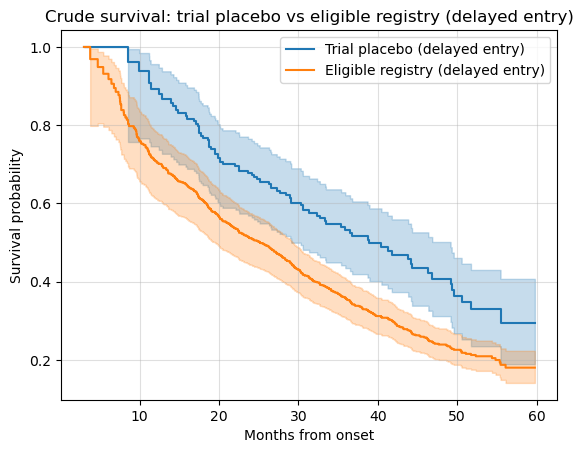

In [34]:

# KM curves with delayed entry
km_trial = km_fit(trial_placebo, "Trial placebo (delayed entry)")
km_reg   = km_fit(eligible_registry, "Eligible registry (delayed entry)")

plot_two_km(km_trial, km_reg, title="Crude survival: trial placebo vs eligible registry (delayed entry)")


In [36]:

# RMST difference at tau = 36 months from onset
tau = 36
rmst_trial = rmst_from_km(km_trial, tau)
rmst_reg   = rmst_from_km(km_reg, tau)
print(f"RMST@{tau}m trial: {rmst_trial:.2f}, registry: {rmst_reg:.2f}, diff: {rmst_trial-rmst_reg:.2f} months")


RMST@36m trial: 28.29, registry: 23.21, diff: 5.08 months


In [ ]:
# 1) Drop impossible rows for left truncation
df_lt = df[df["t_obs"] > df["entry"]].copy()

print("Dropped:", len(df) - len(df_lt))
print("Remaining:", len(df_lt))

# 2) Fit Cox with entry_col
# Cox model with only S_trial, with left truncation
cph = CoxPHFitter()
cph.fit(df_lt[["entry","t_obs","event","S_trial"]],
        duration_col="t_obs", event_col="event", entry_col="entry")
cph.print_summary()

Dropped: 641
Remaining: 1168


<lifelines.CoxPHFitter: fitted with 1168 total observations, 580 right-censored observations>
             duration col = 't_obs'
                event col = 'event'
                entry col = 'entry'
      baseline estimation = breslow
   number of observations = 1168
number of events observed = 588
   partial log-likelihood = -3619.76
         time fit was run = 2026-03-04 11:07:26 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
S_trial   -0.28      0.75      0.12           -0.52           -0.05                0.59                0.96

           cmp to     z    p  -log2(p)
covariate                             
S_trial      0.00 -2.33 0.02      5.67
---
Concordance = 0.52
Partial AIC = 7241.52
log-likelihood ratio test = 5.83 on 1 df
-log2(p) of ll-ratio test = 5.99

### 3) (Point 2) Landmark analysis (alternative to left truncation)

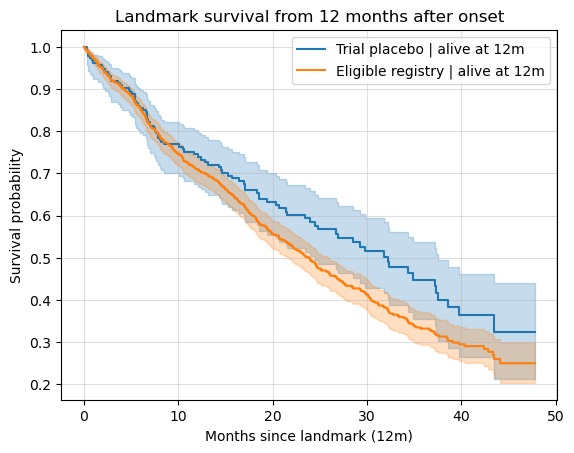

<lifelines.CoxPHFitter: fitted with 1224 total observations, 590 right-censored observations>
             duration col = 't_landmark'
                event col = 'event_landmark'
      baseline estimation = breslow
   number of observations = 1224
number of events observed = 634
   partial log-likelihood = -4095.54
         time fit was run = 2026-03-04 10:33:19 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
S_trial   -0.22      0.80      0.11           -0.45            0.00                0.64                1.00

           cmp to     z    p  -log2(p)
covariate                             
S_trial      0.00 -1.94 0.05      4.27
---
Concordance = 0.51
Partial AIC = 8193.07
log-likelihood ratio test = 3.99 on 1 df
-log2(p) of ll-ratio test = 4.45

In [13]:
def landmark_dataset(df, L=12):
    # keep those who survive beyond L
    d = df[df["t_obs"] > L].copy()
    # redefine time origin at L
    d["t_landmark"] = d["t_obs"] - L
    d["event_landmark"] = d["event"]
    return d

L = 12
d_land = landmark_dataset(df, L=L)

km_trial_L = KaplanMeierFitter().fit(
    d_land.loc[d_land["S_trial"]==1, "t_landmark"],
    d_land.loc[d_land["S_trial"]==1, "event_landmark"],
    label=f"Trial placebo | alive at {L}m"
)
km_reg_L = KaplanMeierFitter().fit(
    d_land.loc[d_land["S_trial"]==0, "t_landmark"],
    d_land.loc[d_land["S_trial"]==0, "event_landmark"],
    label=f"Eligible registry | alive at {L}m"
)

ax = km_trial_L.plot_survival_function(ci_show=True)
km_reg_L.plot_survival_function(ax=ax, ci_show=True)
ax.set_title(f"Landmark survival from {L} months after onset")
ax.set_xlabel(f"Months since landmark ({L}m)")
ax.set_ylabel("Survival probability")
ax.grid(True, alpha=0.4)
plt.show()

# Cox at landmark
cph_L = CoxPHFitter()
cph_L.fit(d_land[["t_landmark","event_landmark","S_trial"]], duration_col="t_landmark", event_col="event_landmark")
cph_L.print_summary()

### 4) (Point 3) Case-mix adjusted survival bias (Cox with delayed entry)

In [43]:
covars = ["S_trial", "age", "sex_male", "bulbar", "dx_delay", "fvc"]

cph_adj = CoxPHFitter()
cph_adj.fit(
    df_lt[["entry","t_obs","event"] + covars],
    duration_col="t_obs",
    event_col="event",
    entry_col="entry"
)
cph_adj.print_summary()

<lifelines.CoxPHFitter: fitted with 1168 total observations, 580 right-censored observations>
             duration col = 't_obs'
                event col = 'event'
                entry col = 'entry'
      baseline estimation = breslow
   number of observations = 1168
number of events observed = 588
   partial log-likelihood = -3545.63
         time fit was run = 2026-03-04 11:21:21 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
S_trial   -0.10      0.91      0.12           -0.34            0.14                0.71                1.15
age        0.04      1.04      0.00            0.03            0.05                1.03                1.05
sex_male   0.06      1.06      0.09           -0.11            0.23                0.90                1.26
bulbar     0.61      1.84      0.10            0.41            0.81                1.51                2.25
dx_delay  -0.05      0.95      0.01           -0.07           -0.03                0.94                0.97
fvc       -0.02      0.98      0.00           -0.02           -0.01                0.98                0.99

           cmp to     z      p  -log2(p)
covariate                               
S_trial      0.00 -0.80   0.43      1.23
age          0.00  9.38 <0.005     67.07
sex_male     0.00  0.70   0.48      1.06
bulbar       0.00  6.04 <0.005     29.26
dx_delay     0.00 -5.20 <0.005     22.29
fvc          0.00 -5.46 <0.005     24.32
---
Concordance = 0.65
Partial AIC = 7103.26
log-likelihood ratio test = 154.09 on 6 df
-log2(p) of ll-ratio test = 99.58

### (Point 4) Participation model + selection weighting + weighted survival

In [45]:

X_cols = ["age", "sex_male", "bulbar", "dx_delay", "fvc", "entry"]
X = df_lt[X_cols].copy()
y = df_lt["S_trial"].values

# Scale covariates for stable logistic regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

logit = LogisticRegression(max_iter=2000)
logit.fit(X_scaled, y)

df_lt["p_trial"] = logit.predict_proba(X_scaled)[:, 1]
df_lt.head(3)

,source,age,sex_male,bulbar,dx_delay,fvc,entry,t_obs,event,S_trial,p_trial
0,registry,58.013532,1,0,10.890451,73.549743,3.041653,7.581819,1,0,0.093933
1,registry,61.286201,0,1,11.619765,140.000000,7.614332,20.597789,0,0,0.235173
2,registry,54.984484,1,0,7.104686,90.029593,6.280980,19.741427,1,0,0.125179


5.2 Overlap diagnostics

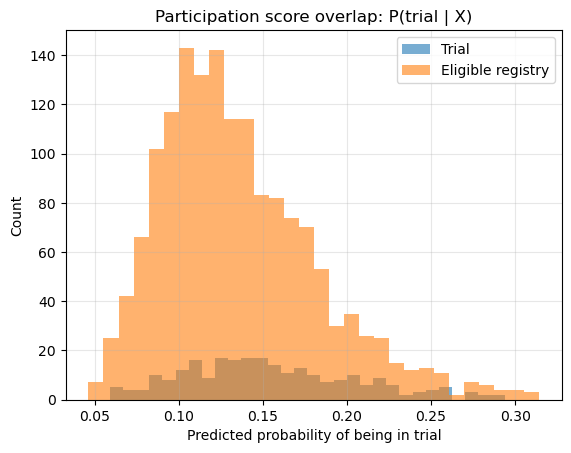

Registry in trial common support: 98.7%


In [ ]:
plt.hist(df_lt.loc[df_lt.S_trial==1, "p_trial"], bins=30, alpha=0.6, label="Trial")
plt.hist(df_lt.loc[df_lt.S_trial==0, "p_trial"], bins=30, alpha=0.6, label="Eligible registry")
plt.title("Participation score overlap: P(trial | X)")
plt.xlabel("Predicted probability of being in trial")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Simple common support check: what fraction of registry falls within trial score range?
trial_min, trial_max = df_lt.loc[df_lt.S_trial==1, "p_trial"].min(), df_lt.loc[df_lt.S_trial==1, "p_trial"].max()
in_support = df_lt.loc[df_lt.S_trial==0, "p_trial"].between(trial_min, trial_max).mean()
print(f"Registry in trial common support: {in_support*100:.1f}%")

#### 5.3 Compute inverse-odds weights and estimate weighted survival

In [46]:
eps = 1e-6
p = np.clip(df_lt["p_trial"].values, eps, 1-eps)

df_lt["w"] = 1.0
df_lt.loc[df_lt["S_trial"]==1, "w"] = (1 - p[df_lt["S_trial"]==1]) / p[df_lt["S_trial"]==1]

# Optional: stabilise / trim extreme weights
w_trial = df_lt.loc[df_lt.S_trial==1, "w"]
print("Trial weights summary:\n", w_trial.describe())
df_lt.head(3)

Trial weights summary:
 count    177.000000
mean       5.550162
std        2.241322
min        1.958696
25%        3.909761
50%        5.276585
75%        6.473531
max       13.817893
Name: w, dtype: float64


,source,age,sex_male,bulbar,dx_delay,fvc,entry,t_obs,event,S_trial,p_trial,w
0,registry,58.013532,1,0,10.890451,73.549743,3.041653,7.581819,1,0,0.093933,1.0
1,registry,61.286201,0,1,11.619765,140.000000,7.614332,20.597789,0,0,0.235173,1.0
2,registry,54.984484,1,0,7.104686,90.029593,6.280980,19.741427,1,0,0.125179,1.0


/opt/anaconda3/envs/digital_twins_2/lib/python3.13/site-packages/lifelines/fitters/kaplan_meier_fitter.py:338: StatisticalWarning: It looks like your weights are not integers, possibly propensity scores then?
  It's important to know that the naive variance estimates of the coefficients are biased. Instead use Monte Carlo to
  estimate the variances. See paper "Variance estimation when using inverse probability of treatment weighting (IPTW) with survival analysis"
  or "Adjusted Kaplan-Meier estimator and log-rank test with inverse probability of treatment weighting for survival data."
                  
  warnings.warn(


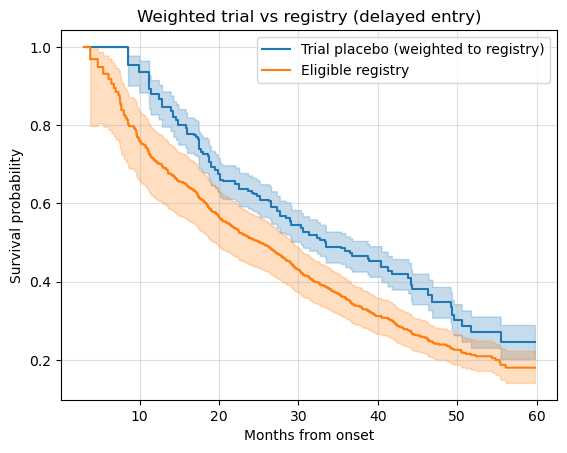

In [47]:

# Trim to reduce variance (toy choice: 1st-99th percentile)
lo, hi = np.percentile(w_trial, [1, 99])
df_lt.loc[df_lt.S_trial==1, "w_trim"] = np.clip(df_lt.loc[df_lt.S_trial==1, "w"], lo, hi)
df_lt.loc[df_lt.S_trial==0, "w_trim"] = 1.0

# Weighted KM for trial, unweighted KM for registry (both with delayed entry)
km_trial_w = km_fit(
    df_lt[df_lt.S_trial==1], "Trial placebo (weighted to registry)",
    weights=df_lt.loc[df_lt.S_trial==1, "w_trim"]
)
km_reg_u = km_fit(df_lt[df_lt.S_trial==0], "Eligible registry")

plot_two_km(km_trial_w, km_reg_u, "Weighted trial vs registry (delayed entry)")

#### Weighted Cox: “trial vs registry” after reweighting

In [48]:
cph_w = CoxPHFitter()
cph_w.fit(
    df_lt[["entry","t_obs","event","S_trial","w_trim"]],
    duration_col="t_obs",
    event_col="event",
    entry_col="entry",
    weights_col="w_trim"
)
cph_w.print_summary()

/opt/anaconda3/envs/digital_twins_2/lib/python3.13/site-packages/lifelines/fitters/coxph_fitter.py:1356: StatisticalWarning: It appears your weights are not integers, possibly propensity or sampling scores then?
It's important to know that the naive variance estimates of the coefficients are biased. Instead a) set `robust=True` in the call to `fit`, or b) use Monte Carlo to
estimate the variances. See paper "Variance estimation when using inverse probability of treatment weighting (IPTW) with survival analysis"

  warnings.warn(


<lifelines.CoxPHFitter: fitted with 1971.94 total observations, 987.335 right-censored observations>
             duration col = 't_obs'
                event col = 'event'
              weights col = 'w_trim'
                entry col = 'entry'
      baseline estimation = breslow
   number of observations = 1971.94
number of events observed = 984.607
   partial log-likelihood = -6601.24
         time fit was run = 2026-03-04 11:31:37 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
S_trial   -0.13      0.88      0.06           -0.25           -0.00                0.78                1.00

           cmp to     z    p  -log2(p)
covariate                             
S_trial      0.00 -2.00 0.05      4.47
---
Concordance = 0.52
Partial AIC = 13204.47
log-likelihood ratio test = 4.01 on 1 df
-log2(p) of ll-ratio test = 4.47

#### Residual gap + sensitivity: E-value for adjusted HR

In [49]:
def e_value(hr):
    # Works for HR either direction; report for protective association too
    hr = float(hr)
    if hr < 1:
        hr = 1/hr
    return hr + np.sqrt(hr*(hr-1))

# Example: take adjusted Cox HR for S_trial
hr_adj = np.exp(cph_adj.params_["S_trial"])
print("Adjusted HR (trial vs registry):", hr_adj)
print("E-value:", e_value(hr_adj))

Adjusted HR (trial vs registry): 0.90634321274993
E-value: 1.4409927120735446
